# adam optimizer

- https://arxiv.org/abs/1412.6980 (Kingma)

AdaGrad + RMSProp = Adam

reimplementation exactly as described in paper

In [35]:
import torch
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [48]:
alpha = 0.001 # stepsize
beta1 = 0.5 # exponential decay rate for the first moment estimates [0, 1)
beta2 = 0.99 # exponential decay rate for the second moment estimates [0, 1)
epsilon = 1e-8 # small constant for numerical stability

x = torch.tensor([1.0], requires_grad=True) # starting value

m0 = 0 # initialize first moment
v0 = 0 # initialize second moment
t = 0 # initialize timestep

plt_x = [x.item()]
while True:
	t += 1

	fn = (x**2).sum()
	fn.backward() # backprop to find grad
	g = x.grad # gradient of function @ x

	m0 = beta1 * m0 + (1 - beta1) * g 	 # update biased first moment estimate
	v0 = beta2 * v0 + (1 - beta2) * g**2 # update biased second moment estimate

	m_hat = m0 / (1 - beta1**t) # compute bias-corrected first moment estimate
	v_hat = v0 / (1 - beta2**t) # compute bias-corrected second moment estimate

	# parameter updates
	with torch.no_grad():
		x -= alpha * m_hat / (v_hat**0.5 + epsilon) 

	plt_x.append(x.item())

	# converged (gradient is zero)
	if abs(g).max() < 1e-3:
		print(f"Converged at step {t}, x = {x.item()}")
		print(f"Final gradient: {g.item()}")
		break

Converged at step 20589, x = 0.04040449112653732
Final gradient: 0.00043057650327682495


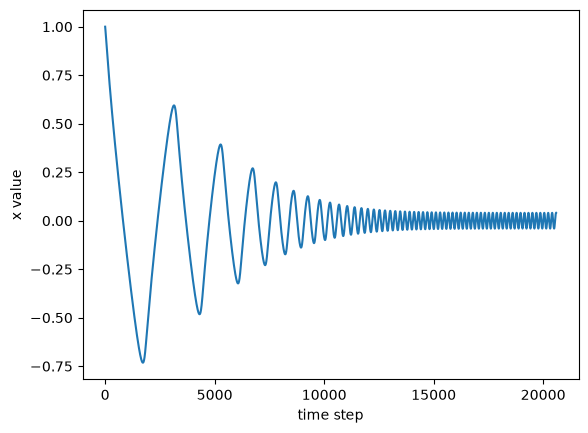

In [49]:
plt.plot(plt_x)
plt.xlabel("time step")
plt.ylabel("x value")
plt.show()

$m_0 := \beta_1 m_0 + (1 - \beta_1) g$

$v_0 := \beta_2 v_0 + (1 - \beta_2) g^2$

$\hat{m} := \frac{m_0}{1 - \beta_1^t}$

$\hat{v} := \frac{v_0}{1 - \beta_2^t}$

$x := x - \alpha \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$

read Momentum + RMSprop for details